In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report ,confusion_matrix
from sklearn.pipeline import Pipeline

In [2]:
data=pd.read_csv("emails.csv")
data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [3]:
data.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [4]:
data.count()

text    5728
spam    5728
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [6]:
data.isna().sum()

text    0
spam    0
dtype: int64

In [7]:
pipeline=Pipeline([
    ("vectorizer",TfidfVectorizer(stop_words="english")),
    ("logistic",LogisticRegression())
])

In [8]:
messages=data[["text"]]
labels=data[["spam"]]

In [9]:
messages.head()

,text
0,Subject: naturally irresistible your corporate...
1,Subject: the stock trading gunslinger fanny i...
2,Subject: unbelievable new homes made easy im ...
3,Subject: 4 color printing special request add...
4,"Subject: do not have money , get software cds ..."


In [10]:
labels.head()

,spam
0,1
1,1
2,1
3,1
4,1


In [11]:
X_train,X_test,y_train,y_test=train_test_split(messages,labels,random_state=42)

In [12]:
print(f"""X_train:{X_train.shape},
        X_test:{X_test.shape},
        y_train:{y_train.shape},
        y_test:{X_test.shape}""")

X_train:(4296, 1),
        X_test:(1432, 1),
        y_train:(4296, 1),
        y_test:(1432, 1)


In [13]:
X_train=X_train.squeeze()
X_test=X_test.squeeze()

In [14]:
y_train=y_train.squeeze()
y_test=y_test.squeeze()


In [15]:
print(f"""X_train:{X_train.shape},
        X_test:{X_test.shape},
        y_train:{y_train.shape},
        y_test:{X_test.shape}""")

X_train:(4296,),
        X_test:(1432,),
        y_train:(4296,),
        y_test:(1432,)


In [16]:
model=pipeline.fit(X_train,y_train)

In [17]:
y_pred=model.predict(X_test)

In [18]:
print("CLASSIFICATION REPORT")
print(classification_report(y_test,y_pred))
print("------------------------------------------")
print("CONFUSION MATRIX")
print(confusion_matrix(y_test,y_pred))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1063
           1       0.99      0.90      0.94       369

    accuracy                           0.97      1432
   macro avg       0.98      0.95      0.96      1432
weighted avg       0.97      0.97      0.97      1432

------------------------------------------
CONFUSION MATRIX
[[1060    3]
 [  36  333]]


In [25]:
param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'vectorizer__max_df': [0.85, 1.0],
    'vectorizer__min_df': [2, 5],                  
    'logistic__C': [0.01, 0.1, 1.0],              
    'logistic__class_weight': [None, 'balanced']
}

In [26]:
grid_search=GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
    )

In [27]:
grid_search.fit(X_train,y_train)
print(f"Best params:{grid_search.best_params_}")
print(f"Best score :{grid_search.best_score_}")



Best params:{'logistic__C': 1.0, 'logistic__class_weight': 'balanced', 'vectorizer__max_df': 1.0, 'vectorizer__min_df': 5, 'vectorizer__ngram_range': (1, 2)}
Best score :0.9758893410289211


In [28]:
best_model=grid_search.best_estimator_
y_pred=best_model.predict(X_test)

In [29]:
print("CLASSIFICATION REPORT")
print(classification_report(y_test,y_pred))
print("------------------------------------------")
print("CONFUSION MATRIX")
print(confusion_matrix(y_test,y_pred))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1063
           1       0.98      0.99      0.99       369

    accuracy                           0.99      1432
   macro avg       0.99      0.99      0.99      1432
weighted avg       0.99      0.99      0.99      1432

------------------------------------------
CONFUSION MATRIX
[[1056    7]
 [   3  366]]


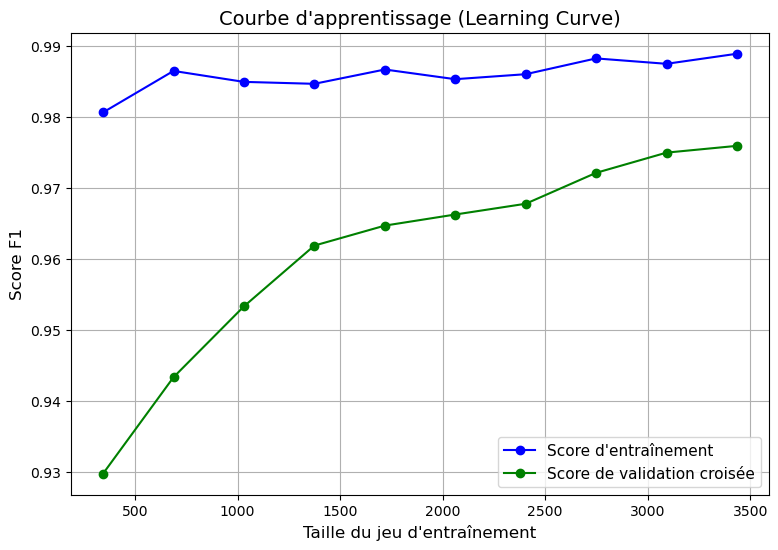

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# 1. Calculer la courbe d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model,       # Votre meilleur modèle optimisé
    X=X_train, 
    y=y_train,
    cv=5,                       # Validation croisée à 5 folds
    scoring='f1',               # On utilise le score F1 (idéal pour les spams)
    train_sizes=np.linspace(0.1, 1.0, 10), # Teste de 10% à 100% des données d'entraînement par paliers
    n_jobs=-1                   # Utilise tous les cœurs du processeur
)

# 2. Calculer les moyennes des scores pour l'entraînement et la validation
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 3. Afficher le graphique avec Matplotlib
plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', label="Score d'entraînement")
plt.plot(train_sizes, test_mean, color='green', marker='o', label="Score de validation croisée")

plt.title("Courbe d'apprentissage (Learning Curve)", fontsize=14)
plt.xlabel("Taille du jeu d'entraînement", fontsize=12)
plt.ylabel("Score F1", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True)
plt.show()

In [33]:
import joblib
joblib.dump(best_model,"spam_detector.pkl")
print("modele sauvegardé avec succes")

modele sauvegardé avec succes
